# Session 08 Practical Activity: Model Evaluation and Cross-Validation

Use cross-validation and metric reports to compare two classifiers for SLA breach risk. The goal is to evaluate models using metrics aligned to risk, cost and business goals.

## 1. Load libraries and dataset

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

import matplotlib.pyplot as plt

DATA_PATH = Path('workplace_model_evaluation_dataset.csv')
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(900, 19)


,request_id,department,channel,region,service_area,customer_type,previous_requests_90d,requester_tenure_months,request_text_length,sentiment_score,updates_first_24h,attachments_count,opened_hour,opened_weekday,sla_breach,priority_level,resolution_hours_after_close,closed_status_after_close,escalation_outcome_after_close
0,SR-00257,Customer Support,Portal,Northern Ireland,Access,Enterprise Client,3,61,244,-0.380,0,1,19,Tue,0,Standard,17.9,Closed within SLA,No escalation
1,SR-00539,Operations,Chat,England,Billing,Enterprise Client,4,79,267,0.339,1,0,15,Tue,0,Low,15.5,Closed within SLA,No escalation
2,SR-00260,IT,Phone,England,Policy,Internal,2,45,207,0.252,2,0,7,Thu,0,Urgent,20.0,Closed within SLA,Team review
3,SR-00486,HR,Portal,England,Access,Public Sector,3,76,193,-0.593,1,0,15,Mon,1,Low,63.3,Closed after SLA,No escalation
4,SR-00454,Operations,Portal,England,Access,SME Client,1,25,188,0.010,4,0,16,Thu,0,Standard,15.6,Closed within SLA,Team review


## 2. Identify target, safe features and leaky fields

The target is `sla_breach`. Post-outcome fields are excluded because they would not be available at prediction time.

In [4]:
target = 'sla_breach'
leaky_cols = ['resolution_hours_after_close', 'closed_status_after_close', 'escalation_outcome_after_close']
id_cols = ['request_id']
feature_cols = [c for c in df.columns if c not in [target, 'priority_level'] + leaky_cols + id_cols]

X = df[feature_cols]
y = df[target]

print('Target rate:', y.mean().round(3))
print('Safe features:', feature_cols)
print('Excluded as leakage:', leaky_cols)

Target rate: 0.428
Safe features: ['department', 'channel', 'region', 'service_area', 'customer_type', 'previous_requests_90d', 'requester_tenure_months', 'request_text_length', 'sentiment_score', 'updates_first_24h', 'attachments_count', 'opened_hour', 'opened_weekday']
Excluded as leakage: ['resolution_hours_after_close', 'closed_status_after_close', 'escalation_outcome_after_close']


## 3. Create a holdout split for final reporting

Cross-validation is used on the training set for comparison. A holdout test set is reserved for a final sanity check.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print('Train target rate:', round(y_train.mean(), 3))
print('Test target rate:', round(y_test.mean(), 3))

Train target rate: 0.428
Test target rate: 0.427


## 4. Build preprocessing and model pipelines

In [6]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

models = {
    'Logistic Regression': Pipeline([
        ('preprocess', preprocess),
        ('classifier', LogisticRegression(max_iter=500, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('preprocess', preprocess),
        ('classifier', RandomForestClassifier(
            n_estimators=180, max_depth=8, random_state=42, class_weight='balanced'
        ))
    ])
}
models

{'Logistic Regression': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['previous_requests_90d',
                                                    'requester_tenure_months',
                                                    'request_text_length',
                                                    'sentiment_score',
                                                    'updates_first_24h',
                                                    'attachments_count',
                                                    'opened_hour']),
                                                  ('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['department', 'channel',
                                                    'region', 'service_area',
                                                

## 5. Cross-validate both classifiers

Use the same folds and the same metrics for a fair comparison.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
    for metric in scoring:
        rows.append({
            'model': name,
            'metric': metric,
            'cv_mean': scores[f'test_{metric}'].mean(),
            'cv_std': scores[f'test_{metric}'].std(),
            'train_mean': scores[f'train_{metric}'].mean(),
            'train_minus_cv': scores[f'train_{metric}'].mean() - scores[f'test_{metric}'].mean()
        })

cv_results = pd.DataFrame(rows)
cv_results.sort_values(['metric','cv_mean'], ascending=[True, False])

,model,metric,cv_mean,cv_std,train_mean,train_minus_cv
5,Random Forest,accuracy,0.614815,0.026084,0.988519,0.373704
0,Logistic Regression,accuracy,0.561481,0.036107,0.628148,0.066667
3,Logistic Regression,f1,0.514564,0.046666,0.592901,0.078337
8,Random Forest,f1,0.473046,0.054678,0.986505,0.513459
6,Random Forest,precision,0.569153,0.040951,0.993036,0.423883
1,Logistic Regression,precision,0.489995,0.039894,0.558113,0.068118
2,Logistic Regression,recall,0.546400,0.075649,0.632341,0.085940
7,Random Forest,recall,0.408046,0.069061,0.980102,0.572056
9,Random Forest,roc_auc,0.601585,0.041476,0.999689,0.398104
4,Logistic Regression,roc_auc,0.587995,0.030207,0.678058,0.090063


## 6. Interpret metric trade-offs

For SLA breach risk, recall may matter if missing a true breach is expensive. Precision may matter if false alarms overwhelm the team. ROC-AUC shows ranking quality across thresholds, not one fixed operating decision.

In [8]:
pivot = cv_results.pivot(index='metric', columns='model', values='cv_mean').round(3)
pivot

model,Logistic Regression,Random Forest
metric,,
accuracy,0.561,0.615
f1,0.515,0.473
precision,0.490,0.569
recall,0.546,0.408
roc_auc,0.588,0.602


## 7. Fit selected model and create holdout report

Choose a model based on business priority, not only the highest overall score. This example selects the model with stronger recall/F1 balance.

In [9]:
selected_name = 'Random Forest'
selected_model = models[selected_name]
selected_model.fit(X_train, y_train)

y_pred = selected_model.predict(X_test)
y_proba = selected_model.predict_proba(X_test)[:, 1]

print('Selected model:', selected_name)
print('Holdout ROC-AUC:', round(roc_auc_score(y_test, y_proba), 3))
print(classification_report(y_test, y_pred, target_names=['No breach','Breach']))

Selected model: Random Forest
Holdout ROC-AUC: 0.596
              precision    recall  f1-score   support

   No breach       0.62      0.74      0.67       129
      Breach       0.52      0.39      0.44        96

    accuracy                           0.59       225
   macro avg       0.57      0.56      0.56       225
weighted avg       0.58      0.59      0.57       225



## 8. Confusion matrix and ROC curve

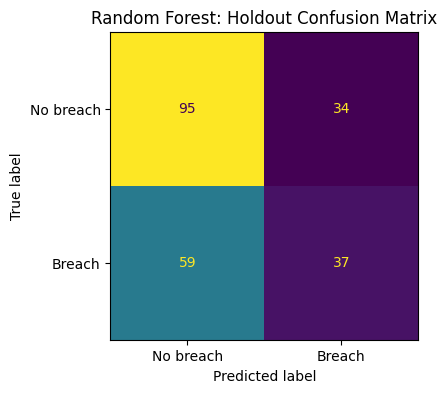

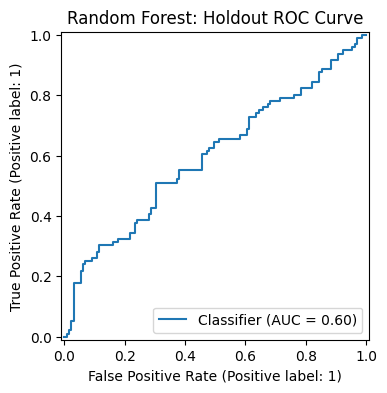

In [10]:
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No breach','Breach'], ax=ax, colorbar=False)
ax.set_title(f'{selected_name}: Holdout Confusion Matrix')
plt.show()

fig, ax = plt.subplots(figsize=(5,4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
ax.set_title(f'{selected_name}: Holdout ROC Curve')
plt.show()

## 9. Student task: write model-card evidence

Complete the template below in markdown.

In [12]:
model_card_section = """
### Model Evaluation Summary

**Intended use:** Early triage of service requests at risk of breaching SLA targets,
to support prioritisation decisions at the point of intake.

**Models compared:** Logistic Regression and Random Forest, both trained with
class_weight='balanced' to account for class imbalance.

**Validation strategy:** 5-fold stratified cross-validation on the training set
(75% of data), with a held-out test set (25%) reserved for a final sanity check.
Stratification ensured each fold preserved the original breach rate of ~43%.

**Metrics and rationale:**
| Metric    | Logistic Regression | Random Forest |
|-----------|-------------------|---------------|
| Accuracy  | 0.562             | 0.615         |
| Precision | 0.490             | 0.569         |
| Recall    | 0.546             | 0.408         |
| F1        | 0.515             | 0.473         |
| ROC-AUC   | 0.588             | 0.602         |

Recall is prioritised because missing a true SLA breach is more costly than a
false alarm — a missed breach affects the customer, while a false alarm only
triggers an unnecessary review.

**Limitations:** Data is synthetic and may not reflect real operational patterns.
Class imbalance (~43% breach rate) limits model confidence. Subgroup performance
across regions and customer types has not been validated. The feature
`updates_first_24h` carries timing risk if prediction is needed before 24 hours
have elapsed. Results must not be used in production without real data validation
and fairness checks.

**Responsible use note:** Before deployment, this model would require fairness
audits across protected characteristics, monitoring for data drift, and human
oversight of all high-stakes triage decisions.
"""

print(model_card_section)


### Model Evaluation Summary

**Intended use:** Early triage of service requests at risk of breaching SLA targets,
to support prioritisation decisions at the point of intake.

**Models compared:** Logistic Regression and Random Forest, both trained with
class_weight='balanced' to account for class imbalance.

**Validation strategy:** 5-fold stratified cross-validation on the training set
(75% of data), with a held-out test set (25%) reserved for a final sanity check.
Stratification ensured each fold preserved the original breach rate of ~43%.

**Metrics and rationale:**
| Metric    | Logistic Regression | Random Forest |
|-----------|-------------------|---------------|
| Accuracy  | 0.562             | 0.615         |
| Precision | 0.490             | 0.569         |
| Recall    | 0.546             | 0.408         |
| F1        | 0.515             | 0.473         |
| ROC-AUC   | 0.588             | 0.602         |

Recall is prioritised because missing a true SLA breach is more costl

## 10. Extension questions

1. What happens if you optimise for precision instead of recall?
2. Which fields were excluded to prevent leakage?
3. What does high cross-validation standard deviation suggest?
4. What should be included in a stakeholder-facing model card?

## Recommended model: Logistic Regression
Logistic Regression is recommended because it has a higher recall score than Random Forest (0.55 vs 0.41). Recall matters most for this task because missing a real SLA breach hurts the customer, whereas a false alarm only triggers an unnecessary internal review. However, this model was trained on synthetic data and may not reflect real operational patterns. In a real organisation there may be other factors that affect SLA breaches that the model has not been trained on. Real data validation would be needed before any deployment.